# lgbm_3class_xfn5d_35f — Performance & SHAP Analysis

**Model**: `lgbm_3class_xfn5d_35f` — LightGBM multiclass signal detector  
**Target**: 5-day excess return of TD vs XFN sector ETF (`target_excess_xfn_5d`)  
**Labels**: Outperform (+1) / Neutral (0) / Underperform (−1), band ±0.30%  
**Features**: 35 (30 base event-style + market/macro + 5 TA: `td_rsqr_60d`, `td_wvma_5d`, `td_wvma_20d`, `td_corr_pv_5d`, `td_beta_20d`)  
**Validation**: 7-fold expanding-window walk-forward (stride-5 offset averaging)

This notebook:
1. Loads the locked 35f artifact and verifies it
2. Re-runs the 7-fold walk-forward evaluation
3. Reports per-fold and aggregate performance (DirAcc, active sign accuracy, coverage)
4. Generates SHAP analysis (global importance + fold heatmap)


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('').resolve()
ROOT = NOTEBOOK_DIR.parents[1]          # project root
EXP_PARENT = ROOT / 'step3_predictive_model/model_experiments'

for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'

print(f'ROOT: {ROOT}')
print(f'Artifact dir: {ARTIFACT_DIR}')

ROOT: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis
Artifact dir: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis/step3_predictive_model/final_model/artifacts


## 1. Load & Verify Artifact

In [2]:
import pickle, json

pkl_files = sorted(ARTIFACT_DIR.glob('lgbm_3class_xfn5d_35f_tuned-*.pkl'))
assert pkl_files, 'Tuned artifact not found — run lgbm_3class_xfn5d_35f_training.ipynb first.'
pkl_path  = pkl_files[-1]   # most recent tuned artifact
json_path   = pkl_path.with_suffix('.json')

with open(pkl_path, 'rb') as f:
    artifact = pickle.load(f)
with open(json_path) as f:
    meta = json.load(f)

model     = artifact['model']
features  = artifact['features']
TARGET    = artifact['target']
THRESHOLD = artifact['threshold']
label_map = artifact['label_map']
inv_map   = artifact['inverse_label_map']
# best_params from training notebook; fall back to original locked defaults
BEST_PARAMS = artifact.get('best_params', dict(
    num_leaves=4, min_child_samples=40, n_estimators=80,
    learning_rate=0.05, feature_fraction=0.8, reg_alpha=0.2, reg_lambda=1.0,
))

assert meta['features'] == features, 'Feature mismatch between pkl and json!'

print(f'Artifact   : {pkl_path.name}')
print(f'Target     : {TARGET}')
print(f'Threshold  : ±{THRESHOLD*100:.1f}%')
print(f'Features   : {len(features)}')
print(f'Best params: {BEST_PARAMS}')


Artifact   : lgbm_3class_xfn5d_35f_tuned-2026-04-22.pkl
Target     : target_excess_xfn_5d
Threshold  : ±0.3%
Features   : 35
Best params: {'learning_rate': 0.05, 'feature_fraction': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'num_leaves': 4, 'min_child_samples': 40, 'n_estimators': 80}


## 2. Load Dataset

In [3]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import E10_FOLDS, STRIDE_EVAL

df = load_dataset()
print(f'Dataset: {len(df)} rows, {df["date"].min().date()} – {df["date"].max().date()}')
print(f'Missing features: {[f for f in features if f not in df.columns]}')

Dataset: 1285 rows, 2021-02-25 – 2026-04-09
Missing features: []


## 3. Walk-Forward Evaluation

In [4]:
import lightgbm as lgb
from sklearn.metrics import f1_score

STRIDE  = STRIDE_EVAL
OFFSETS = list(range(STRIDE))


def fit_predict(train_df, test_df):
    x_tr = train_df[features].fillna(train_df[features].median())
    y_tr = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([label_map[v] for v in y_tr], dtype=int)

    clf = lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        random_state=42, verbose=-1, n_jobs=1,
        **BEST_PARAMS,
    )
    clf.fit(x_tr, y_enc)

    x_te      = test_df[features].fillna(train_df[features].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values           # raw continuous excess return
    preds_enc = clf.predict(x_te)
    preds = np.array([inv_map[p] for p in preds_enc])
    proba = clf.predict_proba(x_te)  # shape (n,3): cols = [P(label=-1), P(label=0), P(label=+1)]
    return clf, preds, y_te_cls, y_te_cont, proba


from sklearn.metrics import roc_auc_score


def offset_metrics(preds, y_true_cls, y_true_cont, dates, proba=None):
    """
    active_asa uses the CONTINUOUS excess return for sign comparison (matching
    run_redesign_experiments.py). This means even a neutral-labeled return that
    moves in the predicted direction counts as directionally correct — the right
    behaviour for a signal-detector framing.

    dir_auc: average of one-vs-rest AUC for the outperform (+1) and underperform (-1)
    signals, computed from class probabilities. proba columns follow label_map:
    col 0 = P(label=-1), col 1 = P(label=0), col 2 = P(label=+1).
    Averaged over the same stride-5 offsets for consistency.
    """
    rows = []
    for off in OFFSETS:
        idx = np.arange(off, len(dates), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        valid_active = active.sum() > 0

        # Dir AUC — gracefully skip offset if a class is absent (can happen in v7's 63-day window)
        d_auc = np.nan
        if proba is not None:
            pb = proba[idx]
            try:
                auc_long  = roc_auc_score((y_cls == 1).astype(int),  pb[:, 2])
                auc_short = roc_auc_score((y_cls == -1).astype(int), pb[:, 0])
                d_auc = (auc_long + auc_short) / 2
            except ValueError:
                pass  # constant class in this offset — leave as nan

        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean()) if valid_active else np.nan,
            'dir_auc':    d_auc,
        })
    r = pd.DataFrame(rows).mean()
    return r


fold_results = []
fold_models  = []
fold_shap_dfs = []

# ── Fold date summary ──────────────────────────────────────────────────────────
print("=== Walk-Forward Fold Dates ===")
print(f"{'Fold':<6} {'Train start':<14} {'Train end':<14} {'Test start':<14} {'Test end':<14} {'Test days':>10}")
print("-" * 72)
train_start_global = df[df[TARGET].notna()]['date'].min().date()
for fold_id, train_end, test_start, test_end in E10_FOLDS:
    tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    te_mask = (df['date'] >= pd.Timestamp(test_start)) & (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna()
    n_test = te_mask.sum()
    print(f"{fold_id:<6} {str(train_start_global):<14} {train_end:<14} {test_start:<14} {test_end:<14} {n_test:>10}")
print("-" * 72)
print(f"  Dataset range : {str(train_start_global)} → {df[df[TARGET].notna()]['date'].max().date()}")
print(f"  Out-of-sample : {E10_FOLDS[0][2]} → {E10_FOLDS[-1][3]}")
print()

for fold_id, train_end, test_start, test_end in E10_FOLDS:
    train_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    test_mask  = (df['date'] >= pd.Timestamp(test_start)) & (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna()
    train_df, test_df = df[train_mask], df[test_mask]

    clf, preds, y_true_cls, y_true_cont, proba = fit_predict(train_df, test_df)
    m = offset_metrics(preds, y_true_cls, y_true_cont, test_df['date'].values, proba=proba)

    # SHAP on test set
    explainer  = shap.TreeExplainer(clf)
    x_te_clean = test_df[features].fillna(train_df[features].median())
    shap_vals  = explainer.shap_values(x_te_clean)
    # Handle both old API (list of arrays per class) and new API (3D array)
    if isinstance(shap_vals, list):
        mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    else:
        sv = np.array(shap_vals)
        if sv.ndim == 3:
            mean_abs = np.abs(sv).mean(axis=(0, 2)) if sv.shape[-1] == 3 else np.abs(sv).mean(axis=(0, 1))
        else:
            mean_abs = np.abs(sv).mean(axis=0)
    shap_ser   = pd.Series(mean_abs, index=features, name=fold_id)
    fold_shap_dfs.append(shap_ser)

    fold_results.append({
        'fold': fold_id, 'train_rows': len(train_df), 'test_rows': len(test_df),
        'train_end': train_end, 'test_start': test_start, 'test_end': test_end,
        **m.to_dict()
    })
    fold_models.append(clf)
    print(f'Fold {fold_id}  mean_acc={m.mean_acc:.3f}  asa={m.active_asa:.3f}  cov={m.active_cov:.3f}  dir_auc={m.dir_auc:.3f}')

results_df = pd.DataFrame(fold_results).set_index('fold')
print('\nDone.')

=== Walk-Forward Fold Dates ===
Fold   Train start    Train end      Test start     Test end        Test days
------------------------------------------------------------------------
v1     2021-02-25     2022-12-30     2023-01-10     2023-06-30            121
v2     2021-02-25     2023-06-30     2023-07-11     2023-12-29            119
v3     2021-02-25     2023-12-29     2024-01-09     2024-06-28            121
v4     2021-02-25     2024-06-28     2024-07-09     2024-12-31            121
v5     2021-02-25     2024-12-31     2025-01-09     2025-06-30            120
v6     2021-02-25     2025-06-30     2025-07-09     2025-12-31            121
v7     2021-02-25     2025-12-31     2026-01-09     2026-04-09             63
------------------------------------------------------------------------
  Dataset range : 2021-02-25 → 2026-04-09
  Out-of-sample : 2023-01-10 → 2026-04-09

Fold v1  mean_acc=0.504  asa=0.647  cov=0.909  dir_auc=0.634


Fold v2  mean_acc=0.470  asa=0.577  cov=0.958  dir_auc=0.599
Fold v3  mean_acc=0.479  asa=0.595  cov=1.000  dir_auc=0.469
Fold v4  mean_acc=0.529  asa=0.611  cov=1.000  dir_auc=0.640


Fold v5  mean_acc=0.400  asa=0.511  cov=0.908  dir_auc=0.532
Fold v6  mean_acc=0.528  asa=0.676  cov=1.000  dir_auc=0.626


Fold v7  mean_acc=0.463  asa=0.619  cov=1.000  dir_auc=0.503

Done.


## 4. Performance Summary

In [5]:
display_cols = ['train_rows', 'test_rows', 'mean_acc', 'macro_f1', 'active_cov', 'active_asa', 'dir_auc']

print('=== Per-Fold Performance ===')
display(results_df[display_cols].round(3))

means = results_df[display_cols].mean()
print('\n=== 7-Fold Mean ===')
print(f'  Mean accuracy        : {means.mean_acc:.3f}')
print(f'  Macro F1             : {means.macro_f1:.3f}')
print(f'  Active coverage      : {means.active_cov:.3f}')
print(f'  Active sign accuracy : {means.active_asa:.3f}')
print(f'  Dir AUC             : {means.dir_auc:.3f}  (avg one-vs-rest AUC for ±1 signals, stride-5 averaged)')

# DirAcc metrics
results_df['DirAcc_strict']   = results_df['active_asa'] * results_df['active_cov']
results_df['DirAcc_abstain50'] = (results_df['active_asa'] * results_df['active_cov']
                                  + 0.5 * (1 - results_df['active_cov']))

print('\n=== DirAcc Metrics (7-fold means) ===')
print(f'  DirAcc_strict   (active-weighted) : {results_df["DirAcc_strict"].mean():.3f}')
print(f'  DirAcc_abstain50 (abstain=50/50)  : {results_df["DirAcc_abstain50"].mean():.3f}')
print(f'  Naive max-bias baseline           : ~0.520  (long-share on excess-return target)')

=== Per-Fold Performance ===


,train_rows,test_rows,mean_acc,macro_f1,active_cov,active_asa,dir_auc
fold,,,,,,,
v1,464,121,0.504,0.419,0.909,0.647,0.634
v2,590,119,0.470,0.363,0.958,0.577,0.599
v3,714,121,0.479,0.243,1.000,0.595,0.469
v4,840,121,0.529,0.380,1.000,0.611,0.640
v5,966,120,0.400,0.296,0.908,0.511,0.532
v6,1091,121,0.528,0.392,1.000,0.676,0.626
v7,1217,63,0.463,0.335,1.000,0.619,0.503



=== 7-Fold Mean ===
  Mean accuracy        : 0.482
  Macro F1             : 0.347
  Active coverage      : 0.968
  Active sign accuracy : 0.605
  Dir AUC             : 0.572  (avg one-vs-rest AUC for ±1 signals, stride-5 averaged)

=== DirAcc Metrics (7-fold means) ===
  DirAcc_strict   (active-weighted) : 0.586
  DirAcc_abstain50 (abstain=50/50)  : 0.603
  Naive max-bias baseline           : ~0.520  (long-share on excess-return target)


## 4b. Per-Class Precision & Recall — Active Signal Group

Precision and recall for the two actionable classes (+1 outperform, −1 underperform), computed
per fold using the same stride-5 offset averaging as all other metrics.

- **Precision**: of the days the model called outperform/underperform, what fraction were actually correct?
- **Recall**: of the days that actually were outperform/underperform, what fraction did the model catch?

**Does recall_out + recall_under equal accuracy? No.**
Recall is a per-class rate — its denominator is the count of actual instances of *that class*.
Accuracy's denominator is *all rows* (including neutral). In practice the raw sum will exceed 1.0
(e.g. 7-fold avg: 0.514 + 0.672 = 1.186 ≠ accuracy 0.482). The only way to recover accuracy from
recalls is to take the weighted average across all 3 classes, weighted by actual class frequency —
which is exactly what accuracy computes by definition. The code below cross-checks this (`acc_check`).

In [16]:
from sklearn.metrics import precision_score, recall_score

pr_rows = []

for i, (fold_id, train_end, test_start, test_end) in enumerate(E10_FOLDS):
    train_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    test_mask  = (df['date'] >= pd.Timestamp(test_start)) & (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna()
    train_df, test_df = df[train_mask], df[test_mask]

    X_te      = test_df[features].fillna(train_df[features].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values          # continuous excess return for ASA
    preds_enc = fold_models[i].predict(X_te)
    preds     = np.array([inv_map[p] for p in preds_enc])

    # Stride-5 offset averaging — consistent with all other metrics
    prec_out_l, prec_und_l = [], []
    rec_out_l,  rec_und_l  = [], []
    asa_out_l,  asa_und_l  = [], []   # class-level ASA vs continuous return
    acc_check_l            = []

    for off in OFFSETS:
        idx      = np.arange(off, len(preds), STRIDE)
        p_off    = preds[idx]
        y_cls    = y_te_cls[idx]
        y_cont   = y_te_cont[idx]

        prec_out_l.append(precision_score(y_cls, p_off, labels=[1],  average='macro', zero_division=0))
        prec_und_l.append(precision_score(y_cls, p_off, labels=[-1], average='macro', zero_division=0))
        rec_out_l.append( recall_score(   y_cls, p_off, labels=[1],  average='macro', zero_division=0))
        rec_und_l.append( recall_score(   y_cls, p_off, labels=[-1], average='macro', zero_division=0))
        acc_check_l.append((p_off == y_cls).mean())

        # ASA by class: direction correct vs continuous return (band-free)
        pred_out   = (p_off == 1)
        pred_under = (p_off == -1)
        asa_out_l.append(float((y_cont[pred_out]   > 0).mean()) if pred_out.sum()   > 0 else np.nan)
        asa_und_l.append(float((y_cont[pred_under] < 0).mean()) if pred_under.sum() > 0 else np.nan)

    pr_rows.append({
        'fold':       fold_id,
        'prec_out':   np.mean(prec_out_l),
        'rec_out':    np.mean(rec_out_l),
        'asa_out':    np.nanmean(asa_out_l),
        'prec_under': np.mean(prec_und_l),
        'rec_under':  np.mean(rec_und_l),
        'asa_under':  np.nanmean(asa_und_l),
        'acc_check':  np.mean(acc_check_l),
    })

pr_df = pd.DataFrame(pr_rows).set_index('fold')

# ── Per-fold table ─────────────────────────────────────────────────────────────
print('=== Per-Fold Precision / Recall / ASA — Active Signal Classes ===\n')
print('ASA = direction correct vs continuous return (band-free); Prec/Rec use banded labels.\n')
display_pr = pr_df[['prec_out', 'rec_out', 'asa_out',
                     'prec_under', 'rec_under', 'asa_under', 'acc_check']].copy()
display_pr.columns = ['Prec OUT', 'Rec OUT', 'ASA OUT',
                      'Prec UNDER', 'Rec UNDER', 'ASA UNDER', 'Acc (check)']
display(display_pr.round(3))

# ── 7-fold mean ────────────────────────────────────────────────────────────────
m = pr_df.mean()
print('\n=== 7-Fold Mean ===')
print(f'  Outperform   — precision: {m.prec_out:.3f}  recall: {m.rec_out:.3f}  ASA: {m.asa_out:.3f}')
print(f'  Underperform — precision: {m.prec_under:.3f}  recall: {m.rec_under:.3f}  ASA: {m.asa_under:.3f}')
print(f'  Combined ASA (from Section 4): {results_df["active_asa"].mean():.3f}')
print(f'  Acc (cross-check vs Section 4): {m.acc_check:.3f}  '
      f'(matches mean_acc={results_df["mean_acc"].mean():.3f})')

# ── Recall vs accuracy note ────────────────────────────────────────────────────
print(f'\n  rec_out + rec_under = {m.rec_out:.3f} + {m.rec_under:.3f}'
      f' = {m.rec_out + m.rec_under:.3f}  ≠  accuracy ({m.acc_check:.3f})'
      '  — different denominators; cannot sum.')

=== Per-Fold Precision / Recall / ASA — Active Signal Classes ===

ASA = direction correct vs continuous return (band-free); Prec/Rec use banded labels.



,Prec OUT,Rec OUT,ASA OUT,Prec UNDER,Rec UNDER,ASA UNDER,Acc (check)
fold,,,,,,,
v1,0.565,0.596,0.666,0.504,0.647,0.625,0.504
v2,0.451,0.669,0.563,0.548,0.485,0.626,0.470
v3,0.167,0.054,0.233,0.513,0.890,0.633,0.479
v4,0.590,0.447,0.619,0.507,0.845,0.609,0.529
v5,0.758,0.333,0.820,0.312,0.721,0.374,0.400
v6,0.527,0.887,0.687,0.561,0.497,0.656,0.528
v7,0.556,0.613,0.706,0.357,0.617,0.524,0.463



=== 7-Fold Mean ===
  Outperform   — precision: 0.516  recall: 0.514  ASA: 0.613
  Underperform — precision: 0.472  recall: 0.672  ASA: 0.578
  Combined ASA (from Section 4): 0.605
  Acc (cross-check vs Section 4): 0.482  (matches mean_acc=0.482)

  rec_out + rec_under = 0.514 + 0.672 = 1.186  ≠  accuracy (0.482)  — different denominators; cannot sum.


## 5. SHAP Global Feature Importance — Outperform vs Underperform

Per-class mean |SHAP| averaged across all 7 walk-forward folds. Top 10 features for each actionable class shown side by side.

Fold v1 done
Fold v2 done
Fold v3 done
Fold v4 done
Fold v5 done
Fold v6 done
Fold v7 done


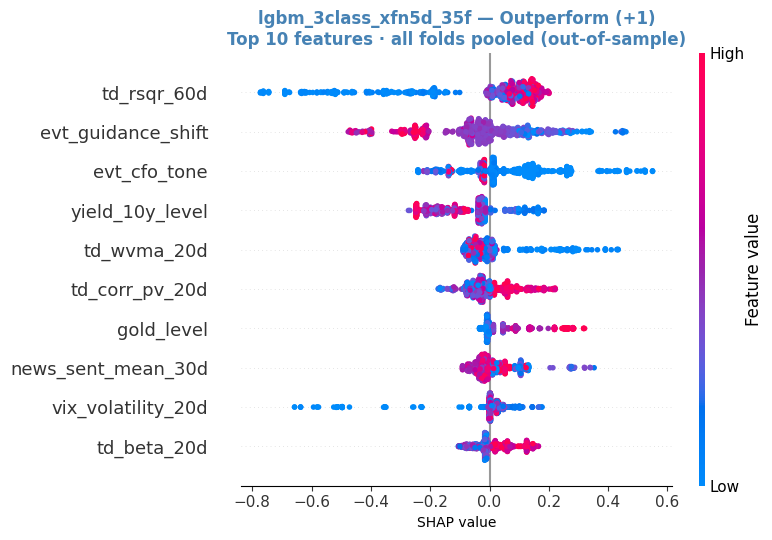

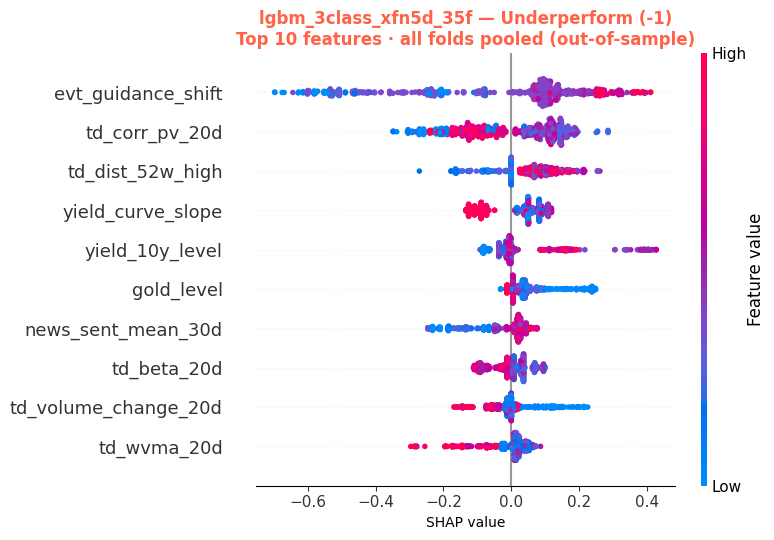

Top-10 Outperform (mean |SHAP| across folds):
td_rsqr_60d           0.167191
evt_guidance_shift    0.118737
evt_cfo_tone          0.112466
yield_10y_level       0.099171
gold_level            0.064965
td_wvma_20d           0.061935
td_corr_pv_20d        0.055809
td_beta_20d           0.049525
news_sent_mean_30d    0.047772
vix_volatility_20d    0.047607

Top-10 Underperform (mean |SHAP| across folds):
evt_guidance_shift      0.203361
td_corr_pv_20d          0.120479
td_dist_52w_high        0.079318
yield_curve_slope       0.076882
yield_10y_level         0.053994
gold_level              0.050958
news_sent_mean_30d      0.049182
td_beta_20d             0.047043
td_volume_change_20d    0.039045
td_wvma_20d             0.037776


In [6]:
# Recompute per-class SHAP per fold; store raw matrices for reuse in section 7
TOP_GLOBAL = 10

fold_sv_out   = []   # (n_test, 35) outperform SHAP per fold
fold_sv_under = []   # (n_test, 35) underperform SHAP per fold
fold_x_te     = []   # test-set feature matrix per fold
fold_shap_out_dfs   = []
fold_shap_under_dfs = []

for fold_idx, (fold_id, train_end, test_start, test_end) in enumerate(E10_FOLDS):
    train_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    test_mask  = (
        (df['date'] >= pd.Timestamp(test_start)) &
        (df['date'] <= pd.Timestamp(test_end)) &
        df[TARGET].notna()
    )
    train_df = df[train_mask]
    test_df  = df[test_mask]
    x_te     = test_df[features].fillna(train_df[features].median())

    explainer = shap.TreeExplainer(fold_models[fold_idx])
    sv        = explainer.shap_values(x_te)

    if isinstance(sv, list):
        sv_out, sv_under = sv[2], sv[0]
    else:
        sv_arr = np.array(sv)
        if sv_arr.ndim == 3 and sv_arr.shape[-1] == 3:
            sv_out, sv_under = sv_arr[:, :, 2], sv_arr[:, :, 0]
        else:
            sv_out, sv_under = sv_arr[2], sv_arr[0]

    fold_sv_out.append(sv_out)
    fold_sv_under.append(sv_under)
    fold_x_te.append(x_te.reset_index(drop=True))
    fold_shap_out_dfs.append(
        pd.Series(np.abs(sv_out).mean(axis=0), index=features, name=fold_id))
    fold_shap_under_dfs.append(
        pd.Series(np.abs(sv_under).mean(axis=0), index=features, name=fold_id))
    print(f'Fold {fold_id} done')

df_out   = pd.DataFrame(fold_shap_out_dfs)
df_under = pd.DataFrame(fold_shap_under_dfs)
imp_out   = df_out.mean().sort_values(ascending=False)
imp_under = df_under.mean().sort_values(ascending=False)

# ── Pool all folds → one figure per class (avoids shap subplot conflicts) ─────
all_sv_out   = np.vstack(fold_sv_out)
all_sv_under = np.vstack(fold_sv_under)
all_x_te     = pd.concat(fold_x_te, ignore_index=True)

top_out_idx   = [features.index(f) for f in imp_out.head(TOP_GLOBAL).index]
top_under_idx = [features.index(f) for f in imp_under.head(TOP_GLOBAL).index]
top_out_feats   = [features[i] for i in top_out_idx]
top_under_feats = [features[i] for i in top_under_idx]

for sv_all, top_feats, top_idx, label, color in [
    (all_sv_out,   top_out_feats,   top_out_idx,   'Outperform (+1)',   'steelblue'),
    (all_sv_under, top_under_feats, top_under_idx, 'Underperform (-1)', 'tomato'),
]:
    sv_slice = sv_all[:, top_idx]
    x_slice  = all_x_te[top_feats].reset_index(drop=True)

    plt.figure(figsize=(13, 7))
    shap.summary_plot(
        sv_slice, x_slice,
        feature_names=top_feats,
        plot_type='dot',
        max_display=TOP_GLOBAL,
        show=False,
        color_bar=True,
    )
    plt.title(
        f'lgbm_3class_xfn5d_35f — {label}\n'
        f'Top {TOP_GLOBAL} features · all folds pooled (out-of-sample)',
        fontsize=12, fontweight='bold', color=color,
    )
    plt.xlabel('SHAP value', fontsize=10)
    plt.tight_layout()
    plt.show()

print('Top-10 Outperform (mean |SHAP| across folds):')
print(imp_out.head(10).to_string())
print('\nTop-10 Underperform (mean |SHAP| across folds):')
print(imp_under.head(10).to_string())


## 6. SHAP Stability Across Folds (Heatmap)

Top-10 features per class, showing how importance shifts fold-by-fold.

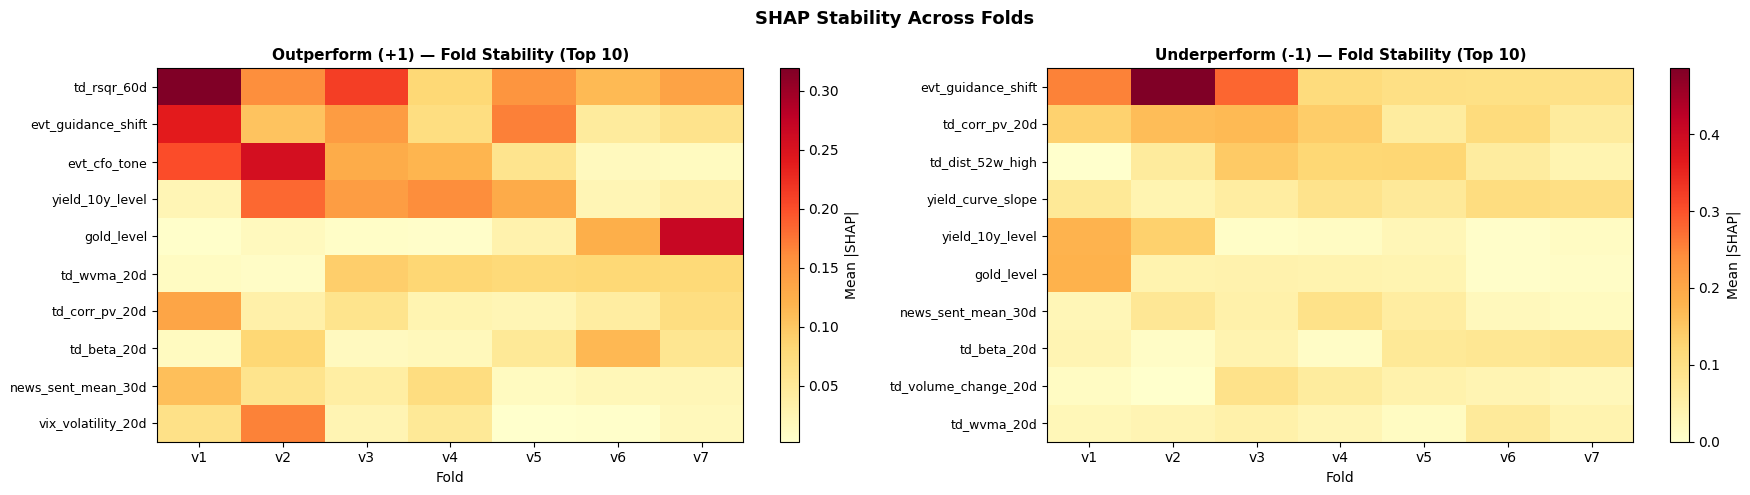

In [7]:
TOP_HEAT = 10

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, df_cls, imp_cls, label in [
    (axes[0], df_out,   imp_out,   'Outperform (+1)'),
    (axes[1], df_under, imp_under, 'Underperform (-1)'),
]:
    top  = imp_cls.head(TOP_HEAT).index.tolist()
    heat = df_cls[top].T   # (n_features, n_folds)

    im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([f'v{i+1}' for i in range(len(heat.columns))], fontsize=10)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top, fontsize=9)
    ax.set_xlabel('Fold')
    ax.set_title(f'{label} — Fold Stability (Top {TOP_HEAT})',
                 fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Mean |SHAP|')

plt.suptitle('SHAP Stability Across Folds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Per-Fold Beeswarm — Top-5 Features (Outperform & Underperform)

For each fold: the 5 features with highest mean |SHAP| for that class in that fold, shown side by side. Each dot = one test-set observation; colour encodes feature value (blue = low, red = high).

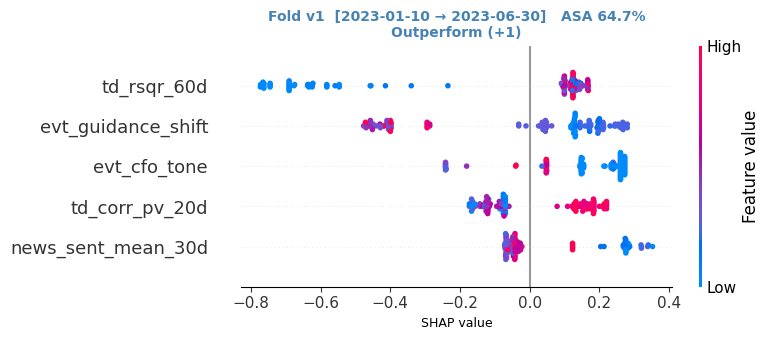

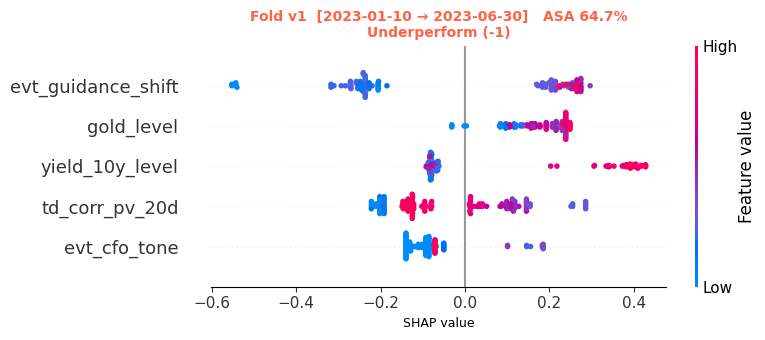

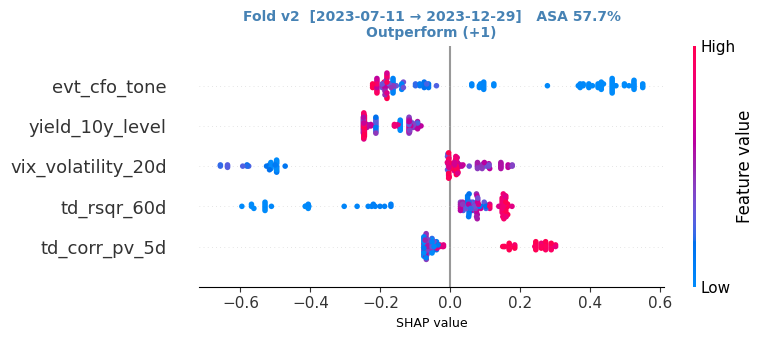

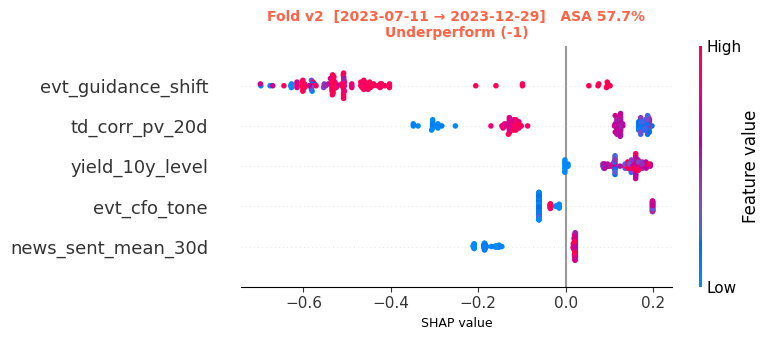

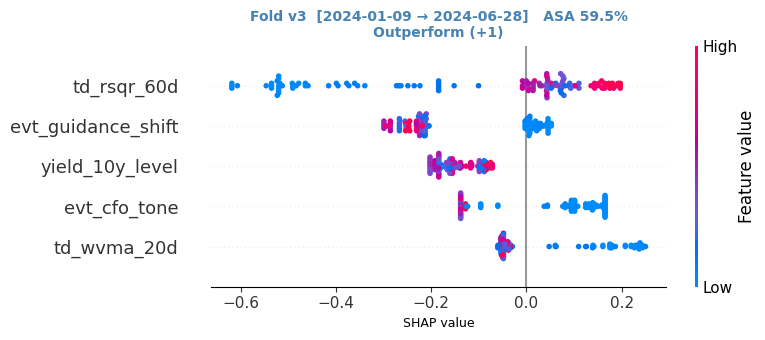

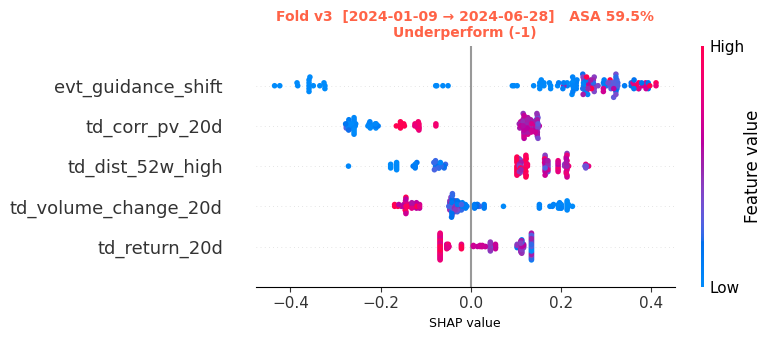

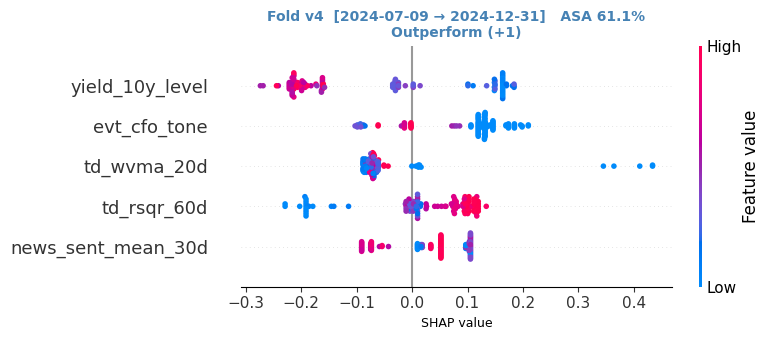

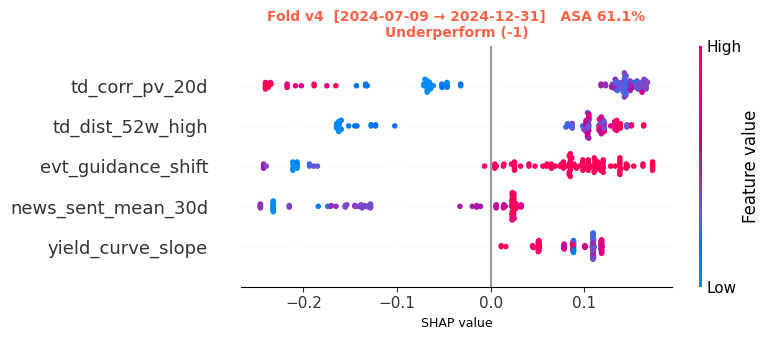

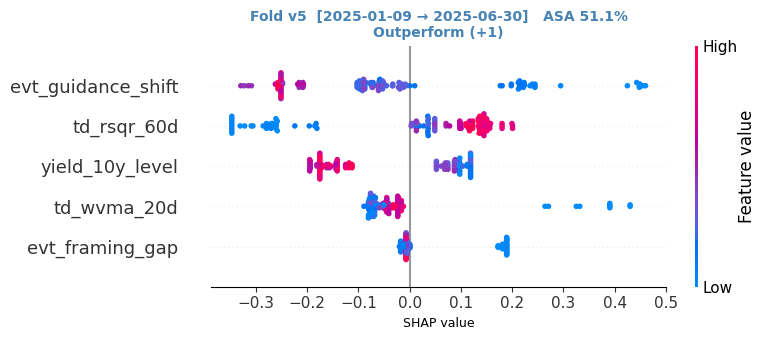

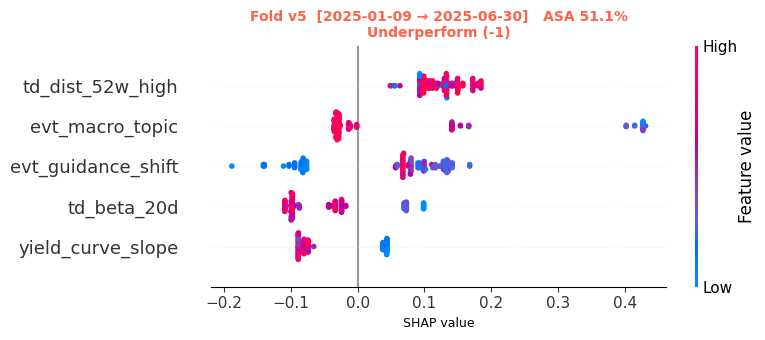

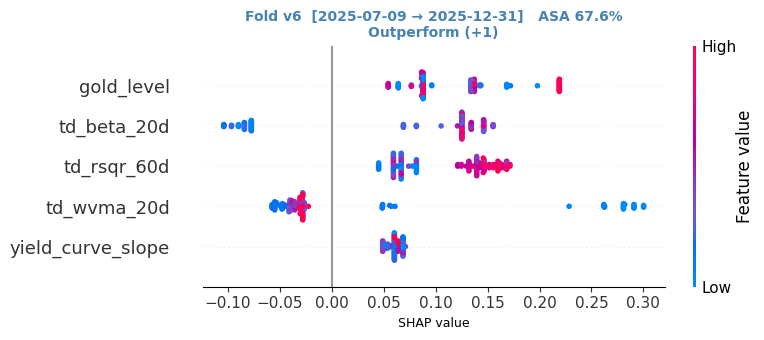

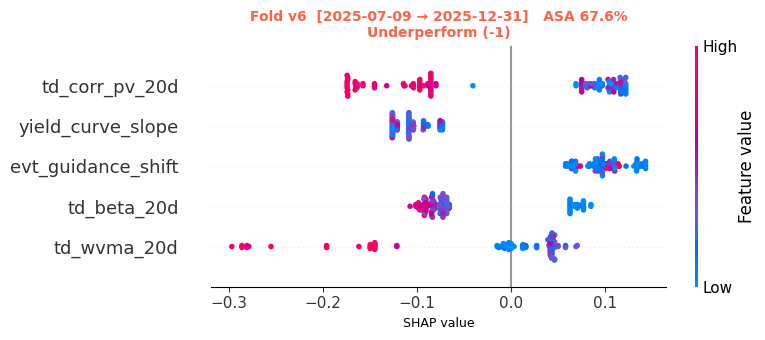

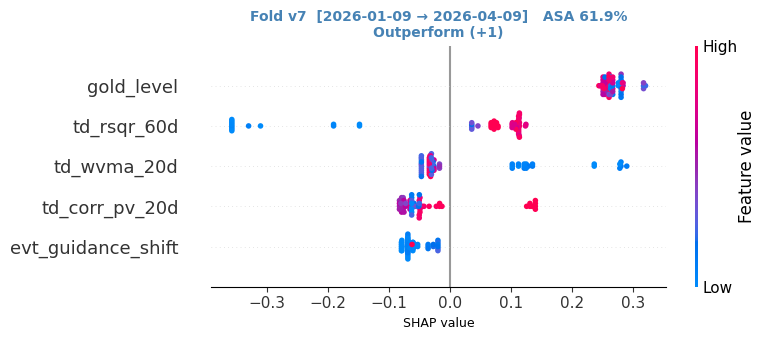

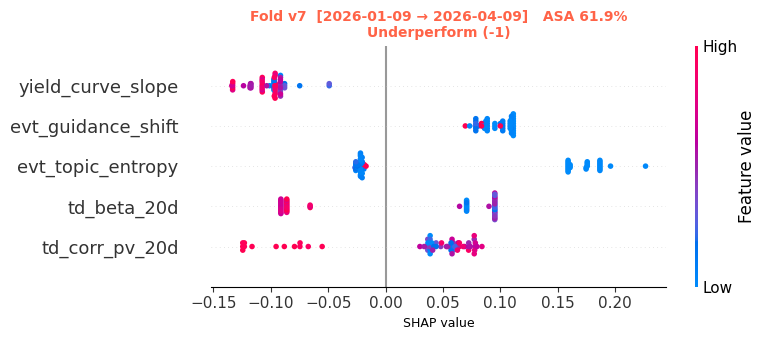

In [8]:
TOP_N = 5

for fold_idx, (fold_id, train_end, test_start, test_end) in enumerate(E10_FOLDS):
    x_te     = fold_x_te[fold_idx]
    sv_out   = fold_sv_out[fold_idx]
    sv_under = fold_sv_under[fold_idx]

    top5_out   = df_out.iloc[fold_idx].sort_values(ascending=False).head(TOP_N).index.tolist()
    top5_under = df_under.iloc[fold_idx].sort_values(ascending=False).head(TOP_N).index.tolist()
    top5_out_idx   = [features.index(f) for f in top5_out]
    top5_under_idx = [features.index(f) for f in top5_under]
    asa_val = results_df.loc[fold_id, 'active_asa']
    fold_hdr = f'Fold {fold_id}  [{test_start} → {test_end}]   ASA {asa_val:.1%}'

    for sv_cls, top5, idx_list, label, color in [
        (sv_out,   top5_out,   top5_out_idx,   'Outperform (+1)',   'steelblue'),
        (sv_under, top5_under, top5_under_idx, 'Underperform (-1)', 'tomato'),
    ]:
        sv_slice = sv_cls[:, idx_list]
        x_slice  = x_te[top5]

        plt.figure(figsize=(13, 4.5))
        shap.summary_plot(
            sv_slice, x_slice,
            feature_names=top5,
            plot_type='dot',
            max_display=TOP_N,
            show=False,
            color_bar=True,
        )
        plt.title(
            f'{fold_hdr}\n{label}',
            fontsize=10, fontweight='bold', color=color,
        )
        plt.xlabel('SHAP value', fontsize=9)
        plt.tight_layout()
        plt.show()


## 8. Feature List (Audit)

All features grouped by block for reproducibility.

In [9]:
feature_groups = {
    'Market / Price': ['td_return_5d', 'td_return_20d', 'td_volatility_20d',
                       'td_vs_xfn_5d', 'td_vs_tsx_5d', 'td_corr_pv_20d',
                       'td_volume_change_20d', 'td_dist_52w_high'],
    'Rates / Macro':  ['yield_curve_slope', 'yield_10y_level'],
    'Global Risk':    ['vix_volatility_20d', 'dxy_level', 'gold_level', 'fx_usdcad_level'],
    'News Flow':      ['news_sent_mean_30d', 'news_count_30d', 'days_since_last_news'],
    'Timing':         ['days_since_call', 'is_earnings_week'],
    'NLP Event':      ['evt_ceo_tone', 'evt_cfo_tone', 'evt_framing_gap',
                       'evt_aml_pressure', 'evt_aml_shift', 'evt_guidance_strength',
                       'evt_guidance_shift', 'evt_macro_topic', 'evt_topic_entropy',
                       'evt_news_tone', 'evt_news_flow'],
    'TA / Qlib':      ['td_rsqr_60d', 'td_wvma_5d', 'td_wvma_20d',
                       'td_corr_pv_5d', 'td_beta_20d'],
}

all_listed = sum(feature_groups.values(), [])
assert sorted(all_listed) == sorted(features), 'Feature group mismatch!'

for group, feats in feature_groups.items():
    print(f'\n{group} ({len(feats)} features):')
    for f in feats:
        print(f'  - {f}')

print(f'\nTotal: {len(features)} features ✓')



Market / Price (8 features):
  - td_return_5d
  - td_return_20d
  - td_volatility_20d
  - td_vs_xfn_5d
  - td_vs_tsx_5d
  - td_corr_pv_20d
  - td_volume_change_20d
  - td_dist_52w_high

Rates / Macro (2 features):
  - yield_curve_slope
  - yield_10y_level

Global Risk (4 features):
  - vix_volatility_20d
  - dxy_level
  - gold_level
  - fx_usdcad_level

News Flow (3 features):
  - news_sent_mean_30d
  - news_count_30d
  - days_since_last_news

Timing (2 features):
  - days_since_call
  - is_earnings_week

NLP Event (11 features):
  - evt_ceo_tone
  - evt_cfo_tone
  - evt_framing_gap
  - evt_aml_pressure
  - evt_aml_shift
  - evt_guidance_strength
  - evt_guidance_shift
  - evt_macro_topic
  - evt_topic_entropy
  - evt_news_tone
  - evt_news_flow

TA / Qlib (5 features):
  - td_rsqr_60d
  - td_wvma_5d
  - td_wvma_20d
  - td_corr_pv_5d
  - td_beta_20d

Total: 35 features ✓
